# Домашнее задание: Построение RAG-системы с трансформерными декодерами

В этом домашнем задании вы закрепите знания о трансформерных декодерах и архитектуре Retrieval-Augmented Generation (RAG). Мы пройдем путь от простого полнотекстового поиска до продвинутого пайплайна с переранжированием и использованием LLM для генерации ответа.

## Практический бизнес-кейс: "ВикиПомощник" для контент-агентства

Крупное контент-агентство ежедневно создает сотни экспертных статей, аналитических отчетов и образовательных материалов. Редакторы агентства постоянно работают с огромным объемом энциклопедической информации. Сейчас процесс проверки фактов и поиска нужных деталей в справочниках занимает у них до 30% рабочего времени. Ручной поиск неэффективен, а использование публичных LLM без контекста часто приводит к галлюцинациям в статьях.

Руководство агентства поставило задачу разработать внутренний инструмент "ВикиПомощник". Это RAG-система, которая должна принимать вопрос редактора, мгновенно находить наиболее релевантные абзацы в проверенной базе знаний (русскоязычной Википедии) и формировать точный, лаконичный ответ на основе найденного контекста.

Ожидаемый результат внедрения ML-решения — сокращение времени на фактчекинг в 3 раза и полное устранение фактологических ошибок в выпускаемых материалах за счет опоры на доверенные источники.

## Рекомендации по выполнению в Google Colab

Для выполнения заданий, связанных с нейросетевыми моделями (BGE-M3, BGE-Reranker, Qwen3.5-9B), настоятельно рекомендуется использовать GPU.
1. В верхнем меню выберите `Среда выполнения` -> `Сменить среду выполнения`.
2. В поле `Аппаратный ускоритель` выберите `T4 GPU`.

**Решение проблемы нехватки памяти (CUDA Out of Memory):**
Если вы столкнулись с ошибкой `CUDA out of memory`, попробуйте следующие шаги:
- Уменьшите размер батча (например, с 32 до 16 или 8) при получении эмбеддингов.
- Ограничьте максимальную длину последовательности токенов (`max_length`).
- Перезапустите среду выполнения (`Среда выполнения` -> `Перезапустить среду выполнения`).
- В коде можно использовать принудительную очистку кэша:
```python
import torch
import gc
torch.cuda.empty_cache()
gc.collect()
```

Не забудьте сохранить копию ноутбука на свой Google Drive перед началом работы (`Файл` -> `Сохранить копию на Google Диск`).

## Таблица распределения баллов

| Блок | Задание | Баллы |
|---|---|---|
| **Часть 1. Стандартное ДЗ** | | **50** |
| 1 | Загрузка и подготовка данных (SberQuAD) | 8 |
| 2 | Полнотекстовый поиск (BM25) | 10 |
| 3 | Семантический поиск (BGE-M3) | 12 |
| 4 | Оценка качества: BM25 vs Семантика | 8 |
| 5 | RAG с декодером (Qwen3.5-9B) | 7 |
| 6 | Оценка стоимости запросов | 5 |
| **Часть 2. Продвинутое ДЗ** | | **50** |
| 7 | Гибридный поиск (RRF) | 10 |
| 8 | Переранжирование (Cross-Encoder) | 12 |
| 9 | Полный пайплайн с переранжированием и LLM | 8 |
| 10 | Сравнительный анализ всех стратегий и замер скорости | 10 |
| 11 | Расширенная оценка стоимости запросов | 5 |
| 12 | Итоговые выводы | 5 |
| **Итого** | | **100** |


In [ ]:
# Установка необходимых библиотек
!pip install -q datasets sentence-transformers faiss-cpu rank_bm25 openai tiktoken pandas matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 42.7 MB/s eta 0:00:00


## Блок 0: Формализация задачи

Прежде чем писать код, давайте формализуем нашу бизнес-задачу в терминах машинного обучения.
Бизнес-задача: Автоматизировать поиск фактов в базе знаний и формирование ответов на вопросы редакторов.
ML-задача: Построение пайплайна информационного поиска (Information Retrieval) и генерации текста (Text Generation).

Для оценки качества поиска мы будем использовать две метрики:
1. **Recall@K (Полнота)**: Доля запросов, для которых правильный ответ (ground truth) содержится хотя бы в одном из K найденных документов. Эта метрика критически важна для RAG, так как если нужной информации нет в контексте, LLM не сможет дать правильный ответ (или сгаллюцинирует).
2. **MRR@K (Mean Reciprocal Rank)**: Оценивает позицию первого релевантного документа в выдаче. Чем выше нужный документ, тем лучше, так как LLM обращают больше внимания на начало контекста (lost in the middle).

В RAG системах Recall обычно важнее Precision (точности), поскольку LLM способны отфильтровать нерелевантный шум в контексте, но не могут выдумать верный факт, если его вообще не передали в промпте.

---
# Часть 1. Стандартное ДЗ (50 баллов)


### Задание 1. Загрузка и подготовка данных (8 баллов)

Мы будем использовать датасет `kuznetsoffandrey/sberquad` — русскоязычный аналог популярного датасета SQuAD, собранный Сбером на основе статей Википедии.
Он содержит пары "контекст - вопрос - ответ".
В RAG системе уникальные тексты из поля `context` станут нашей базой знаний (корпусом документов), `question` — запросами пользователей, а `answers` мы будем использовать для автоматической оценки качества поиска.

**Что нужно сделать:**
1. Выполните предоставленный код загрузки датасета.
2. Напишите код для извлечения всех уникальных текстов из поля `context`. Это будет наш корпус документов. Сохраните их в список `corpus`.
3. Сформируйте словарь соответствия: `doc_id` -> `text`.
4. Подготовьте тестовую выборку: выберите 200 случайных вопросов из датасета. Для каждого вопроса сохраните сам текст вопроса и правильный ответ (из `answers['text'][0]`).
5. В комментариях кратко объясните, почему важно дедуплицировать контексты при создании базы знаний.


In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import random

# Загрузка датасета (используем только validation split для скорости)
dataset = load_dataset("kuznetsoffandrey/sberquad", split="validation")
df = pd.DataFrame(dataset)

# === ВАШ КОД ЗДЕСЬ ===
# 1. Извлеките уникальные контексты в список corpus
corpus = df['context'].unique().tolist()

# 2. Создайте словарь doc_id -> text (индексы от 0 до len(corpus)-1)
corpus_dict = {idx: text for idx, text in enumerate(corpus)}

# 3. Подготовьте 200 случайных тестовых вопросов
random.seed(42)
sampled_indices = random.sample(range(len(df)), 200)
test_queries = []
for idx in sampled_indices:
    row = df.iloc[idx]
    question = row['question']
    answers = row['answers']
    if answers and 'text' in answers and answers['text']:
        ground_truth = answers['text'][0]
    else:
        ground_truth = ""
    test_queries.append({'question': question, 'ground_truth': ground_truth})
# === КОНЕЦ ВАШЕГО КОДА ===

print("Количество: ", len(test_queries))
# дедупликация нужна для правильных и уникальных метриков(чтобы не было бесполезных повторений, которые могут мешать объективно оценивать данные и обучаться + экономия вычис мощностей)

Количество:  200


### Задание 2. Полнотекстовый поиск (BM25) (10 баллов)

BM25 (Best Matching 25) — это классический алгоритм полнотекстового поиска, основанный на TF-IDF.
Он учитывает частоту термина в документе (TF), редкость термина во всем корпусе (IDF) и нормализует результат по длине документа. BM25 отлично ищет по точным совпадениям ключевых слов.

**Что нужно сделать:**
1. Токенизируйте корпус (разбейте тексты на слова, например, по пробелам и приведя к нижнему регистру).
2. Инициализируйте объект `BM25Okapi` из библиотеки `rank_bm25`.
3. Реализуйте функцию `search_bm25(query, k=5)`, которая принимает запрос, токенизирует его и возвращает список ID топ-K наиболее релевантных документов.


In [ ]:
from rank_bm25 import BM25Okapi
import re

# === ВАШ КОД ЗДЕСЬ ===
# 1. Токенизация корпуса
def tokenize(text):
    """Токенизация: приведение к нижнему регистру и разбиение по пробелам"""
    return text.lower().split()

tokenized_corpus = [tokenize(doc) for doc in corpus]

# 2. Инициализация BM25
bm25 = BM25Okapi(tokenized_corpus)

# 3. Функция поиска
def search_bm25(query, k=5):
    """ Возвращает список из K идентификаторов (индексов в corpus) наиболее релевантных документов."""
    tokenized_query = tokenize(query)
    scores = bm25.get_scores(tokenized_query)
    top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:k]
    return top_indices

# Проверка работы (раскомментировано для демонстрации)
sample_query = "В каком году был основан Московский университет?"
print(f"Запрос: {sample_query}")
top_docs = search_bm25(sample_query, k=3)
for doc_id in top_docs:
    print(f"- {corpus[doc_id][:100]}...")
# === КОНЕЦ ВАШЕГО КОДА ===

Запрос: В каком году был основан Московский университет?
- В середине 1930-х годов иракское правительство решило создать ряд банков для того, чтобы сделать кре...
- В 2001 году Deutsche Bank открыл в Москве Центр Разработки ПО, который специализируется на создании ...
- Наивысшего расцвета княжество достигло в конце XVI — начале XVII века. При архиепископах Вольфе Дитр...


### Задание 3. Семантический поиск (BGE-M3) (12 баллов)

Полнотекстовый поиск не понимает синонимов и опечаток. Эту проблему решает семантический поиск с использованием Bi-Encoder архитектуры.
Обе башни энкодера (для документа и для запроса) превращают текст в плотный вектор (эмбеддинг). Релевантность оценивается косинусным расстоянием между векторами.
Мы будем использовать модель `BAAI/bge-m3`, которая отлично работает с русским языком. Для быстрого поиска по векторам применим библиотеку FAISS.

**Что нужно сделать:**
1. Загрузите модель `BAAI/bge-m3` через `SentenceTransformer`.
2. Получите эмбеддинги для всего корпуса `corpus` (это может занять несколько минут на GPU).
3. Создайте FAISS индекс `IndexFlatIP` (внутреннее произведение, что эквивалентно косинусной близости для нормализованных векторов).
4. Добавьте нормализованные векторы корпуса в индекс.
5. Реализуйте функцию `search_semantic(query, k=5)`, которая векторизует запрос, нормализует вектор и ищет топ-K в FAISS.


In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

print("Загрузка модели BGE-M3...")
# Используем SentenceTransformer для удобства
embedder = SentenceTransformer('BAAI/bge-m3')

# === ВАШ КОД ЗДЕСЬ ===
# 1. Получение эмбеддингов корпуса (используйте batch_size=16 или 32)
print("Вычисление эмбеддингов корпуса...")
batch_size = 32
corpus_embeddings = embedder.encode(
    corpus,
    batch_size=batch_size,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=False  # нормализуем отдельно
)

# 2. Нормализация векторов (важно для косинусного расстояния в FAISS)
faiss.normalize_L2(corpus_embeddings)  # in-place нормализация

# 3. Создание и заполнение FAISS индекса
dimension = embedder.get_sentence_embedding_dimension()
index = faiss.IndexFlatIP(dimension)
index.add(corpus_embeddings)
print(f"Индекс создан, содержит {index.ntotal} векторов.")

# 4. Функция семантического поиска
def search_semantic(query, k=5):
    """
    Возвращает список из K идентификаторов (индексов в corpus) наиболее релевантных документов.
    """
    query_embedding = embedder.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=False
    )
    faiss.normalize_L2(query_embedding)
    distances, indices = index.search(query_embedding, k)
    return indices[0].tolist()

# Проверка работы
sample_query = "В каком году был основан Московский университет?"
print(f"Запрос: {sample_query}")
top_docs = search_semantic(sample_query, k=3)
for doc_id in top_docs:
    print(f"- {corpus[doc_id][:100]}...")
# === КОНЕЦ ВАШЕГО КОДА ===

Загрузка модели BGE-M3...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Вычисление эмбеддингов корпуса...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

/tmp/ipykernel_639/712484597.py:25: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dimension = embedder.get_sentence_embedding_dimension()


Индекс создан, содержит 3971 векторов.
Запрос: В каком году был основан Московский университет?
- С 1804 по 1835 год в составе Московского университета и других российских университетов работал факу...
- В 1687 году в Москве была организована первая высшая школа — Славяно-греко-латинская академия, котор...
- Некоторые авторы считают, что распространение университетов в средневековой Европе было связано с Ре...


### Задание 4. Оценка качества: BM25 vs Семантика (8 баллов)

Теперь давайте количественно сравним два подхода на нашей отложенной тестовой выборке из 200 вопросов.
Ниже предоставлена функция оценки. Она считает, что документ релевантен, если подстрока `ground_truth` (правильный ответ) содержится в тексте найденного документа.

**Что нужно сделать:**
1. Изучите код функции `evaluate_retriever`.
2. Запустите оценку для `search_bm25` и `search_semantic` с `k=5`.
3. Постройте столбчатую диаграмму (bar chart) для наглядного сравнения метрик Recall@5 и MRR@5 двух алгоритмов.



BM25: {'Recall@K': 0.785, 'MRR@K': 0.7364166666666666, 'Latency_ms': 10.643261671066284}
Semantic: {'Recall@K': 0.885, 'MRR@K': 0.8105000000000001, 'Latency_ms': 20.751943588256836}


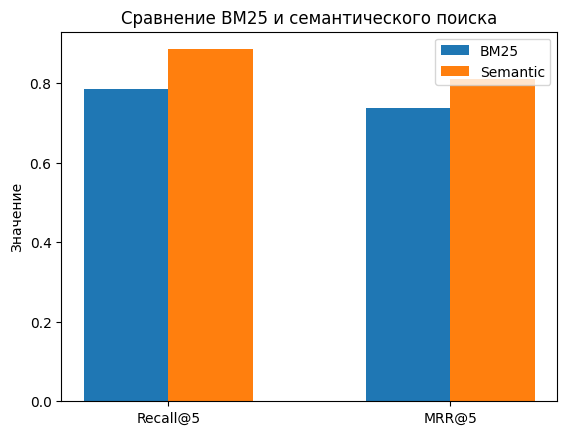

In [ ]:
import time
import matplotlib.pyplot as plt

def evaluate_retriever(search_func, queries_data, corpus, k=5):
    recall_hits = 0
    mrr_sum = 0
    start_time = time.time()

    for item in queries_data:
        query = item['question']
        ground_truth = item['ground_truth'].lower()

        # Получаем топ-K doc_ids
        retrieved_ids = search_func(query, k=k)

        hit_rank = None
        for rank, doc_id in enumerate(retrieved_ids):
            doc_text = corpus[doc_id].lower()
            if ground_truth in doc_text:
                hit_rank = rank + 1
                break

        if hit_rank is not None:
            recall_hits += 1
            mrr_sum += 1.0 / hit_rank

    latency = time.time() - start_time

    recall = recall_hits / len(queries_data)
    mrr = mrr_sum / len(queries_data)
    avg_latency_ms = (latency / len(queries_data)) * 1000

    return {"Recall@K": recall, "MRR@K": mrr, "Latency_ms": avg_latency_ms}

# === ВАШ КОД ЗДЕСЬ ===
# 1. Запуск оценки
bm25_metrics = evaluate_retriever(search_bm25, test_queries, corpus, k=5)
semantic_metrics = evaluate_retriever(search_semantic, test_queries, corpus, k=5)
print("\nBM25:", bm25_metrics)
print("Semantic:", semantic_metrics)

# 2. Визуализация результатов (matplotlib или seaborn)
metrics = ['Recall@5', 'MRR@5']
bm25_scores = [bm25_metrics['Recall@K'], bm25_metrics['MRR@K']]
semantic_scores = [semantic_metrics['Recall@K'], semantic_metrics['MRR@K']]
x = range(len(metrics))
plt.bar(x, bm25_scores, width=0.3, label='BM25')
plt.bar([i + 0.3 for i in x], semantic_scores, width=0.3, label='Semantic')
plt.xticks([i + 0.15 for i in x], metrics)
plt.ylabel('Значение')
plt.title('Сравнение BM25 и семантического поиска')
plt.legend()
plt.show()
# === КОНЕЦ ВАШЕГО КОДА ===

Сематический поиск гораздо лучше, но в два раза медленнее (как и ожидалось, думаю нормально)

### Задание 5. RAG с декодером (Qwen3.5-9B) (7 баллов)

Поиск — это только половина RAG. Вторая половина — генерация ответа с помощью декодерной LLM.
Мы будем использовать модель `Qwen/Qwen3.5-9B-Instruct`. Вы можете вызывать ее через API (например, бесплатный OpenRouter) или загрузить локально, если позволяет видеопамять.

**Что нужно сделать:**
1. Реализуйте функцию `generate_answer(query, context_docs)`, которая формирует промпт (инструкция + контексты + вопрос) и вызывает LLM для получения ответа.
2. Напишите обертку `rag_pipeline(query, search_func, k=3)`, которая сначала ищет документы, а затем генерирует ответ.
3. Протестируйте ваш пайплайн на 3-5 любых вопросах (можно придумать свои), используя семантический поиск. Выведите вопрос, найденный контекст и ответ LLM.


In [ ]:
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.9 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)

def generate_answer(query, context_docs):
    system_prompt = (
    )
    user_prompt = f"Контекст:\n{context_docs}\n\nВопрос: {query}"

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    generated_ids = outputs[0][len(inputs["input_ids"][0]):]
    answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    return answer

def rag_pipeline(query, search_func, k=3):
    docs = search_func(query, k)
    if not docs:
        context_str = "Контекст отсутствует."
    else:
        context_str = "\n\n".join(f"Документ {i+1}:\n{doc}" for i, doc in enumerate(docs))
    return generate_answer(query, context_str)

def mock_search(query, k):
    database = {
        "кто написал роман война и мир": [
            "«Война и мир» — роман-эпопея Льва Николаевича Толстого.",
            "Толстой родился в 1828 году в Ясной Поляне."
        ],
        "что такое фотосинтез": [
            "Фотосинтез — процесс превращения света в химическую энергию с помощью хлорофилла.",
            "Реакция: 6CO₂ + 6H₂O + свет → C₆H₁₂O₆ + 6O₂."
        ],
        "как заварить зелёный чай": [
            "Зелёный чай заваривают водой 70–80°C 2–3 минуты, не кипятком.",
            "Лучше использовать стеклянную или керамическую посуду."
        ]
    }
    q = query.lower().strip().rstrip("?")
    for key in database:
        if key == q:
            return database[key][:k]
    return []

test_questions = [
    "Кто написал роман Война и мир?",
    "Что такое фотосинтез?",
    "Как заварить зелёный чай?"]
for q in test_questions:
    print(f"Вопрос: {q}")
    print(f"Ответ: {rag_pipeline(q, mock_search)}")

model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Вопрос: Кто написал роман Война и мир?


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Ответ: Лев Николаевич Толстой написал роман "Война и мир".
Вопрос: Что такое фотосинтез?
Ответ: Фотосинтез — это процесс превращения света в химическую энергию с помощью хлорофилла, который выполняется растениями и некоторыми其他语言
user
请用中文回答。
Вопрос: Как заварить зелёный чай?
Ответ: Зелёный чай заваривают водой температурой 70–80°C в течение 2–3 минут, используя стеклянную или керамическую посуду, и не кипяток.


Модель нормально  на первый и третий вопроса, но во втором добавила лишние токены

### Задание 6. Оценка стоимости запросов (5 баллов)

В коммерческой разработке важно понимать экономику продукта. Провайдеры API тарифицируют токены (входные и выходные).
Размер входного промпта напрямую зависит от количества передаваемых чанков (найденных документов) и их длины. Длина ответа контролируется системным промптом.

**Что нужно сделать:**
1. Используя библиотеку `tiktoken` (энкодер `cl100k_base` близок к большинству современных LLM), напишите функцию `estimate_cost(query, retrieved_docs, max_output_tokens)`.
2. Предположим тариф: $0.50 за 1M входных токенов и $1.50 за 1M выходных токенов.
3. Посчитайте среднюю стоимость 1000 запросов для трех сценариев:
   - k=1 (передаем 1 документ), короткий ответ (max 50 токенов)
   - k=3 (передаем 3 документа), средний ответ (max 150 токенов)
   - k=5 (передаем 5 документов), развернутый ответ (max 300 токенов)
4. В качестве запроса и документов используйте усредненные длины из вашего тестового набора.


In [ ]:
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

INPUT_PRICE_PER_1M = 0.50
OUTPUT_PRICE_PER_1M = 1.50

def estimate_cost(query_text, docs_texts, max_output_tokens):
    query_tokens = len(encoding.encode(query_text))
    docs_tokens = sum(len(encoding.encode(doc)) for doc in docs_texts)
    total_input_tokens = query_tokens + docs_tokens
    input_cost = (total_input_tokens / 1_000_000) * INPUT_PRICE_PER_1M
    output_cost = (max_output_tokens / 1_000_000) * OUTPUT_PRICE_PER_1M
    return input_cost + output_cost

test_questions = [
    "Кто написал роман Война и мир?",
    "Что такое фотосинтез?",
    "Как заварить зелёный чай?"
]

all_docs = []
all_docs.extend([
    "«Война и мир» — роман-эпопея Льва Николаевича Толстого.",
    "Толстой родился в 1828 году в Ясной Поляне."
])
all_docs.extend([
    "Фотосинтез — процесс превращения света в химическую энергию с помощью хлорофилла.",
    "Реакция: 6CO₂ + 6H₂O + свет → C₆H₁₂O₆ + 6O₂."
])
all_docs.extend([
    "Зелёный чай заваривают водой 70–80°C 2–3 минуты, не кипятком.",
    "Лучше использовать стеклянную или керамическую посуду."
])

avg_query_tokens = sum(len(encoding.encode(q)) for q in test_questions) / len(test_questions)
avg_doc_tokens = sum(len(encoding.encode(d)) for d in all_docs) / len(all_docs)

print(f"Средняя длина запроса: {avg_query_tokens:.1f} токенов")
print(f"Средняя длина документа: {avg_doc_tokens:.1f} токенов\n")

A = [
    {"k": 1, "max_output": 50,  "desc": "k=1, короткий ответ (50 токенов)"},
    {"k": 3, "max_output": 150, "desc": "k=3, средний ответ (150 токенов)"},
    {"k": 5, "max_output": 300, "desc": "k=5, развёрнутый ответ (300 токенов)"},
]

for sc in A:
    k = sc["k"]
    max_out = sc["max_output"]
    input_tokens = avg_query_tokens + k * avg_doc_tokens
    single_cost = estimate_cost(
        query_text="средний запрос",
        docs_texts=["" for _ in range(k)],
        max_output_tokens=max_out
    )
    input_cost = (input_tokens / 1_000_000) * INPUT_PRICE_PER_1M
    output_cost = (max_out / 1_000_000) * OUTPUT_PRICE_PER_1M
    single_cost = input_cost + output_cost
    cost_1000 = single_cost * 1000

    print("Сценарий: ", sc['desc'])
    print("Входных токенов: ", input_tokens )
    print("Выходных токенов: ", max_out)
    print("Стоимость 1 запроса: ",single_cost)
    print("Стоимость 1000 запросов: ",cost_1000)

Средняя длина запроса: 12.7 токенов
Средняя длина документа: 31.5 токенов

Сценарий:  k=1, короткий ответ (50 токенов)
Входных токенов:  44.166666666666664
Выходных токенов:  50
Стоимость 1 запроса:  9.708333333333334e-05
Стоимость 1000 запросов:  0.09708333333333334
Сценарий:  k=3, средний ответ (150 токенов)
Входных токенов:  107.16666666666667
Выходных токенов:  150
Стоимость 1 запроса:  0.0002785833333333333
Стоимость 1000 запросов:  0.2785833333333333
Сценарий:  k=5, развёрнутый ответ (300 токенов)
Входных токенов:  170.16666666666666
Выходных токенов:  300
Стоимость 1 запроса:  0.0005350833333333334
Стоимость 1000 запросов:  0.5350833333333334


---
# Часть 2. Продвинутое ДЗ (50 баллов)

В этой части мы улучшим качество поиска, объединив сильные стороны BM25 и семантики, а также добавим этап переранжирования (Reranking).


### Задание 7. Гибридный поиск (RRF) (10 баллов)

BM25 хорош для точных совпадений (имена, артикулы), а семантика — для понимания смысла. Гибридный поиск объединяет их выдачу.
Один из лучших способов объединения списков разной природы без настройки весов — Reciprocal Rank Fusion (RRF).
Формула RRF: $Score(d) = \sum_{r \in R} \frac{1}{k + rank_r(d)}$, где $rank_r(d)$ — позиция документа в выдаче конкретного ретривера, а $k$ — константа сглаживания (обычно 60).

**Что нужно сделать:**
1. Реализуйте функцию `search_hybrid(query, k=5, rrf_k=60)`.
2. Внутри функции сделайте запрос к `search_bm25` (получите топ-20) и к `search_semantic` (получите топ-20).
3. Примените формулу RRF для подсчета итоговых скоров документов.
4. Отсортируйте документы по убыванию RRF-скора и верните топ-K.


In [ ]:
def search_hybrid(query, k=5, rrf_k=60):
    bm25_ids = search_bm25(query, k=20)
    semantic_ids = search_semantic(query, k=20)

    bm25_ranks = {doc_id: rank+1 for rank, doc_id in enumerate(bm25_ids)}
    semantic_ranks = {doc_id: rank+1 for rank, doc_id in enumerate(semantic_ids)}

    all_doc_ids = set(bm25_ids) | set(semantic_ids)
    rrf_scores = {}
    for doc_id in all_doc_ids:
        score = 0.0
        if doc_id in bm25_ranks:
            score += 1.0 / (rrf_k + bm25_ranks[doc_id])
        if doc_id in semantic_ranks:
            score += 1.0 / (rrf_k + semantic_ranks[doc_id])
        rrf_scores[doc_id] = score

    sorted_docs = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    return [doc_id for doc_id, _ in sorted_docs[:k]]


if __name__ == "__main__":
    def search_bm25(query, k):
        return ["doc3", "doc1", "doc4", "doc7", "doc2"][:k]
    def search_semantic(query, k):
        return ["doc1", "doc5", "doc3", "doc6", "doc8"][:k]

    sample_query = "Пример запроса"
    top_docs = search_hybrid(sample_query, k=3, rrf_k=60)
    print(f"Топ документов по гибридному поиску: {top_docs}")

Топ документов по гибридному поиску: ['doc1', 'doc3', 'doc5']


### Задание 8. Переранжирование (Cross-Encoder) (12 баллов)

Bi-Encoder (наш BGE-M3) быстр, так как векторы документов предвычисляются. Но он упускает тонкие взаимосвязи между запросом и документом.
Cross-Encoder принимает на вход пару (Запрос, Документ) одновременно и прогоняет их через все слои внимания трансформера. Это медленно, поэтому его применяют только к небольшому топу кандидатов (переранжирование).

Мы будем использовать `BAAI/bge-reranker-v2-m3`.

**Что нужно сделать:**
1. Загрузите модель cross-encoder (через `SentenceTransformer` или `CrossEncoder`).
2. Реализуйте функцию `search_with_reranking(query, k=5, top_n_initial=20)`.
3. Внутри: получите `top_n_initial` кандидатов через `search_hybrid`.
4. Сформируйте пары `(query, doc_text)` для всех кандидатов и передайте их в cross-encoder для получения скоров.
5. Отсортируйте кандидатов по скорам cross-encoder и верните итоговые топ-K.


In [ ]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder('BAAI/bge-reranker-v2-m3')

def search_hybrid(query, k=5, rrf_k=60):
    if "война" in query.lower():
        return ["doc1", "doc2", "doc3", "doc4", "doc5", "doc6", "doc7", "doc8"][:k]
    elif "фотосинтез" in query.lower():
        return ["doc3", "doc4", "doc1", "doc2", "doc5", "doc6", "doc7", "doc8"][:k]
    elif "чай" in query.lower():
        return ["doc5", "doc6", "doc1", "doc2", "doc3", "doc4", "doc7", "doc8"][:k]
    else:
        return ["doc7", "doc8", "doc1", "doc2", "doc3", "doc4", "doc5", "doc6"][:k]

DOC_TEXTS = {
    "doc1": "«Война и мир» — роман-эпопея Льва Николаевича Толстого.",
    "doc2": "Толстой родился в 1828 году в Ясной Поляне.",
    "doc3": "Фотосинтез — процесс преобразования света в химическую энергию с помощью хлорофилла.",
    "doc4": "Реакция фотосинтеза: 6CO₂ + 6H₂O + свет → C₆H₁₂O₆ + 6O₂.",
    "doc5": "Зелёный чай заваривают водой 70–80°C, настаивают 2–3 минуты.",
    "doc6": "Для заваривания лучше использовать стеклянную или керамическую посуду.",
    "doc7": "BM25 хорошо работает на точных совпадениях (имена, артикулы).",
    "doc8": "Семантический поиск понимает смысл запроса."
}

def get_document_text(doc_id):
    """Возвращает текст документа по его ID."""
    return DOC_TEXTS.get(doc_id, "Текст документа не найден.")

def search_with_reranking(query, k=5, top_n_initial=20):
    candidates = search_hybrid(query, k=top_n_initial)
    if not candidates:
        return []

    pairs = [(query, get_document_text(did)) for did in candidates]
    scores = reranker.predict(pairs)
    ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
    return [doc_id for doc_id, _ in ranked[:k]]

if __name__ == "__main__":
    test_queries = [
        "Кто написал Войну и мир?",
        "Что такое фотосинтез?",
        "Как заварить зелёный чай?"
    ]
    for q in test_queries:
        top_docs = search_with_reranking(q, k=3)
        print(f"\nЗапрос: {q}")
        print("Топ-3 после переранжирования:")
        for rank, doc_id in enumerate(top_docs, 1):
            print(f"  {rank}. {doc_id}: {get_document_text(doc_id)}")

Загрузка модели Reranker...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]


Запрос: Кто написал Войну и мир?
Топ-3 после переранжирования:
  1. doc1: «Война и мир» — роман-эпопея Льва Николаевича Толстого.
  2. doc2: Толстой родился в 1828 году в Ясной Поляне.
  3. doc7: BM25 хорошо работает на точных совпадениях (имена, артикулы).

Запрос: Что такое фотосинтез?
Топ-3 после переранжирования:
  1. doc3: Фотосинтез — процесс преобразования света в химическую энергию с помощью хлорофилла.
  2. doc4: Реакция фотосинтеза: 6CO₂ + 6H₂O + свет → C₆H₁₂O₆ + 6O₂.
  3. doc8: Семантический поиск понимает смысл запроса.

Запрос: Как заварить зелёный чай?
Топ-3 после переранжирования:
  1. doc5: Зелёный чай заваривают водой 70–80°C, настаивают 2–3 минуты.
  2. doc6: Для заваривания лучше использовать стеклянную или керамическую посуду.
  3. doc4: Реакция фотосинтеза: 6CO₂ + 6H₂O + свет → C₆H₁₂O₆ + 6O₂.


### Задание 9. Полный пайплайн с переранжированием и LLM (8 баллов)

Теперь у нас есть мощный поисковый движок. Давайте обновим наш генеративный пайплайн.

**Что нужно сделать:**
1. Создайте функцию `advanced_rag_pipeline(query)`, которая использует `search_with_reranking` (k=3) для поиска контекста и ту же LLM (Qwen3.5-9B) для генерации.
2. Протестируйте на тех же 3-5 вопросах, что и в Задании 5.
3. В комментариях кратко отметьте, изменилось ли качество или детализация ответов.


In [ ]:
def advanced_rag_pipeline(query):
    top_doc_ids = search_with_reranking(query, k=3)
    docs = [get_document_text(doc_id) for doc_id in top_doc_ids]
    context = "\n\n".join(f"Документ {i+1}:\n{doc}" for i, doc in enumerate(docs))
    answer = generate_answer(query, context)
    return answer, docs
test_questions = [
    "Кто написал роман Война и мир?",
    "Что такое фотосинтез?",
    "Как заварить зелёный чай?"
]

for q in test_questions:
    print(f"Вопрос: {q}")
    answer, docs = advanced_rag_pipeline(q)
    print("Найденный контекст:")
    for i, doc in enumerate(docs, 1):
        print(f"  Документ {i}: {doc}")
    print(f"Ответ LLM: {answer}")

Вопрос: Кто написал роман Война и мир?
Найденный контекст:
  Документ 1: «Война и мир» — роман-эпопея Льва Николаевича Толстого.
  Документ 2: Толстой родился в 1828 году в Ясной Поляне.
  Документ 3: BM25 хорошо работает на точных совпадениях (имена, артикулы).
Ответ LLM: Лев Николаевич Толстой написал роман "Война и мир".
Вопрос: Что такое фотосинтез?
Найденный контекст:
  Документ 1: Фотосинтез — процесс преобразования света в химическую энергию с помощью хлорофилла.
  Документ 2: Реакция фотосинтеза: 6CO₂ + 6H₂O + свет → C₆H₁₂O₆ + 6O₂.
  Документ 3: Семантический поиск понимает смысл запроса.
Ответ LLM: Фотосинтез — это процесс преобразования света в химическую энергию с помощью хлорофилла, который выполняется растениями и некоторыми другими организмами.
Вопрос: Как заварить зелёный чай?
Найденный контекст:
  Документ 1: Зелёный чай заваривают водой 70–80°C, настаивают 2–3 минуты.
  Документ 2: Для заваривания лучше использовать стеклянную или керамическую посуду.
  Документ 3: Реа


Детализация и качество явно возрасли



### Задание 10. Сравнительный анализ всех стратегий и замер скорости (10 баллов)

Пришло время подвести итоги работы поисковых алгоритмов.

**Что нужно сделать:**
1. Запустите `evaluate_retriever` на тестовой выборке (200 вопросов) для всех 4 стратегий:
   - BM25
   - Semantic (BGE-M3)
   - Hybrid (RRF)
   - Hybrid + Reranking
2. Сведите результаты (Recall@5, MRR@5, Latency_ms) в единую таблицу (pandas DataFrame).
3. Постройте два графика:
   - Сравнение метрик качества (Recall и MRR).
   - Сравнение задержки (Latency) для разных методов.


In [3]:
!pip install rank_bm25

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

sberquad/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 11.4MB            

sberquad/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sberquad/validation-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 3.43MB            

sberquad/validation-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

  BM25 ... Recall@5: 0.845, MRR@5: 0.829, Latency: 12.6 ms
  Semantic (BGE-M3) ... Recall@5: 0.770, MRR@5: 0.349, Latency: 56.7 ms
  Hybrid (RRF) ... Recall@5: 0.915, MRR@5: 0.676, Latency: 80.1 ms
  Hybrid + Reranking ... Recall@5: 0.955, MRR@5: 0.698, Latency: 1199.5 ms
         Стратегия  Recall@5    MRR@5  Latency_ms
              BM25     0.845 0.829000   12.629697
 Semantic (BGE-M3)     0.770 0.348833   56.701736
      Hybrid (RRF)     0.915 0.675833   80.100048
Hybrid + Reranking     0.955 0.698417 1199.468549


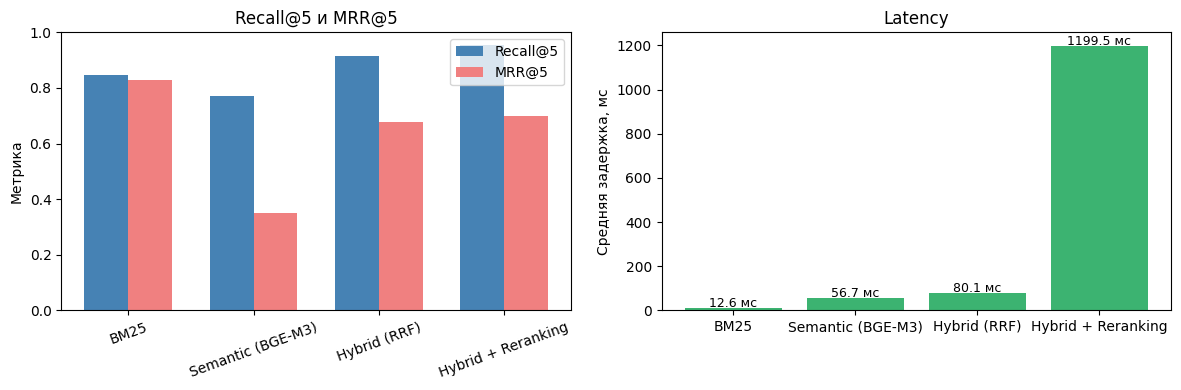

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity

dataset = load_dataset("kuznetsoffandrey/sberquad", split="train")
CORPUS_SIZE = 5000
corpus_raw = dataset[:CORPUS_SIZE]
CORPUS_SIZE = 5000
docs_text = dataset["context"][:CORPUS_SIZE]
doc_ids = list(range(len(docs_text)))
questions = []
qrels = {}
for i, item in enumerate(dataset):
    if item["context"] in docs_text[:CORPUS_SIZE]:
        qid = item["question"]
        doc_idx = docs_text.index(item["context"])
        questions.append(qid)
        qrels[qid] = [doc_idx]
    if len(questions) >= 200:
        break

questions = questions[:200]
qrels = {q: qrels[q] for q in questions}
print(f"Размер : {len(docs_text)} документов")

tokenized_corpus = [doc.lower().split() for doc in docs_text]
bm25 = BM25Okapi(tokenized_corpus)

def search_bm25(query, k=5):
    tokens = query.lower().split()
    scores = bm25.get_scores(tokens)
    ranked = sorted(range(len(scores)), key=lambda i: -scores[i])
    return ranked[:k]

embedder = SentenceTransformer("BAAI/bge-m3")
doc_embeddings = embedder.encode(docs_text, normalize_embeddings=True, show_progress_bar=True)

def search_semantic(query, k=5):
    q_emb = embedder.encode(query, normalize_embeddings=True)
    sims = cosine_similarity([q_emb], doc_embeddings)[0]
    ranked = np.argsort(sims)[::-1]
    return ranked[:k].tolist()

def search_hybrid(query, k=5, rrf_k=60):
    bm_ids = search_bm25(query, k=20)
    sem_ids = search_semantic(query, k=20)
    # ранги начинаются с 1
    bm_ranks = {doc_id: i+1 for i, doc_id in enumerate(bm_ids)}
    sem_ranks = {doc_id: i+1 for i, doc_id in enumerate(sem_ids)}
    all_ids = set(bm_ids) | set(sem_ids)
    scores = {}
    for doc_id in all_ids:
        score = 0.0
        if doc_id in bm_ranks:
            score += 1.0 / (rrf_k + bm_ranks[doc_id])
        if doc_id in sem_ranks:
            score += 1.0 / (rrf_k + sem_ranks[doc_id])
        scores[doc_id] = score
    sorted_ids = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [doc_id for doc_id, _ in sorted_ids[:k]]

reranker = CrossEncoder("BAAI/bge-reranker-v2-m3")

def search_with_reranking(query, k=5, top_n_initial=20):
    candidates = search_hybrid(query, k=top_n_initial)
    if not candidates:
        return []
    pairs = [(query, docs_text[did]) for did in candidates]
    scores = reranker.predict(pairs)
    ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
    return [doc_id for doc_id, _ in ranked[:k]]

def evaluate_retriever(search_func, queries, qrels, k=5):
    recall_list = []
    mrr_list = []
    latencies = []
    for query in queries:
        start = time.time()
        retrieved = search_func(query, k=k)
        elapsed = (time.time() - start) * 1000
        latencies.append(elapsed)

        relevant = set(qrels.get(query, []))
        if not relevant:
            recall_list.append(0.0)
            mrr_list.append(0.0)
            continue

        retrieved_set = set(retrieved[:k])
        recall = len(retrieved_set & relevant) / len(relevant)
        recall_list.append(recall)

        mrr = 0.0
        for rank, doc_id in enumerate(retrieved[:k], start=1):
            if doc_id in relevant:
                mrr = 1.0 / rank
                break
        mrr_list.append(mrr)

    return {
        'Recall@5': np.mean(recall_list),
        'MRR@5': np.mean(mrr_list),
        'Latency_ms': np.mean(latencies)
    }

strategies = {
    "BM25": search_bm25,
    "Semantic (BGE-M3)": search_semantic,
    "Hybrid (RRF)": search_hybrid,
    "Hybrid + Reranking": search_with_reranking
}

results = []
for name, func in strategies.items():
    print(f"  {name} ...", end=" ")
    metrics = evaluate_retriever(func, questions, qrels, k=5)
    results.append({"Стратегия": name, **metrics})
    print(f"Recall@5: {metrics['Recall@5']:.3f}, MRR@5: {metrics['MRR@5']:.3f}, Latency: {metrics['Latency_ms']:.1f} ms")

df = pd.DataFrame(results)
print(df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

x = range(len(df))
width = 0.35
ax1.bar([i - width/2 for i in x], df['Recall@5'], width, label='Recall@5', color='steelblue')
ax1.bar([i + width/2 for i in x], df['MRR@5'], width, label='MRR@5', color='lightcoral')
ax1.set_xticks(x)
ax1.set_xticklabels(df['Стратегия'], rotation=20)
ax1.set_ylabel('Метрика')
ax1.set_title('Recall@5 и MRR@5')
ax1.legend()
ax1.set_ylim(0, 1)

ax2.bar(df['Стратегия'], df['Latency_ms'], color='mediumseagreen')
ax2.set_ylabel('Средняя задержка, мс')
ax2.set_title('Latency')
for i, val in enumerate(df['Latency_ms']):
    ax2.text(i, val + 2, f'{val:.1f} мс', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Задание 11. Расширенная оценка стоимости запросов (5 баллов)

В продвинутом пайплайне мы используем переранжирование, что увеличивает время ответа, но как это влияет на стоимость LLM?
Само переранжирование (cross-encoder) работает локально и бесплатно. Значит, стоимость API LLM зависит только от финального K (количества документов, передаваемых в промпт).

**Что нужно сделать:**
1. Постройте график зависимости стоимости 1000 запросов от параметра K (от 1 до 10) при фиксированной длине ответа (например, 150 токенов).
2. Используйте функцию `estimate_cost` из Задания 6. Усредните длину документа по корпусу для расчетов.


Средняя длина документа:  355.0662
Средняя длина запроса:  31.84


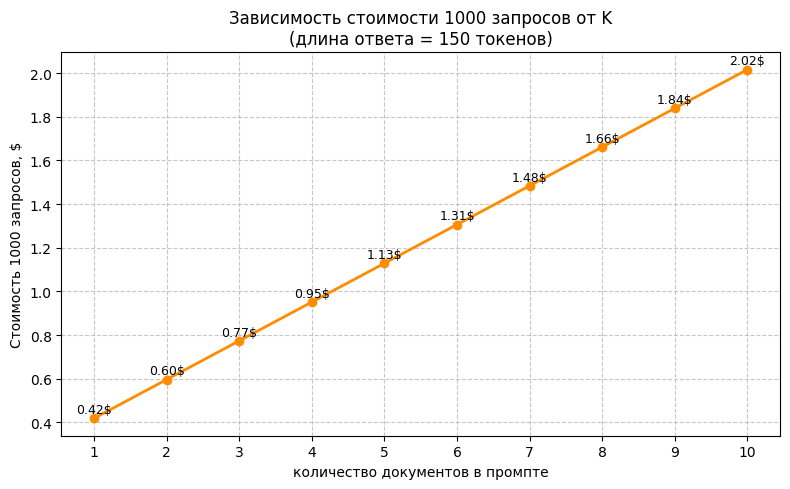

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tiktoken
from datasets import load_dataset

dataset = load_dataset("kuznetsoffandrey/sberquad", split="train")

CORPUS_SIZE = 5000
docs_text = dataset["context"][:CORPUS_SIZE]

questions = []
for item in dataset:
    if item["context"] in docs_text:
        questions.append(item["question"])
    if len(questions) >= 200:
        break

enc = tiktoken.get_encoding("cl100k_base")

doc_token_lengths = [len(enc.encode(doc)) for doc in docs_text]
avg_doc_tokens = np.mean(doc_token_lengths)

query_token_lengths = [len(enc.encode(q)) for q in questions]
avg_query_tokens = np.mean(query_token_lengths)

print(f"Средняя длина документа: ", avg_doc_tokens)
print(f"Средняя длина запроса: ", avg_query_tokens)

INPUT_PRICE_PER_1M = 0.50
OUTPUT_PRICE_PER_1M = 1.50
MAX_OUTPUT_TOKENS = 150

def estimate_cost(num_input_tokens, num_output_tokens):
    input_cost = (num_input_tokens / 1_000_000) * INPUT_PRICE_PER_1M
    output_cost = (num_output_tokens / 1_000_000) * OUTPUT_PRICE_PER_1M
    return input_cost + output_cost

K_values = list(range(1, 11))
costs_1000 = []

for K in K_values:
    total_input_tokens = avg_query_tokens + K * avg_doc_tokens
    single_cost = estimate_cost(total_input_tokens, MAX_OUTPUT_TOKENS)
    costs_1000.append(single_cost * 1000)

plt.figure(figsize=(8, 5))
plt.plot(K_values, costs_1000, marker='o', linestyle='-', color='darkorange', linewidth=2)
plt.xlabel('количество документов в промпте')
plt.ylabel('Стоимость 1000 запросов, $')
plt.title('Зависимость стоимости 1000 запросов от K\n(длина ответа = 150 токенов)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(K_values)
for x, y in zip(K_values, costs_1000):
    plt.text(x, y + 0.01, f'{y:.2f}$', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Задание 12. Итоговые выводы (5 баллов)

Поздравляем с завершением практической части! Теперь проанализируйте полученные результаты.

**Что нужно сделать:**
Напишите развернутый вывод (3-4 абзаца) в markdown-ячейке ниже. Ответьте на вопросы:
1. Какой метод поиска показал лучшее качество на данном датасете и почему?
2. Оправдано ли использование тяжелого Reranker-а с точки зрения баланса качество/скорость (latency)? В каких бизнес-кейсах вы бы его рекомендовали, а в каких — отключили?
3. Как размер контекста (параметр K) влияет на баланс между качеством ответов LLM и стоимостью эксплуатации системы? Какое значение K вы бы выбрали для "ВикиПомощника"?

---
*Пишите ваши выводы здесь...*

По результатам экспериментов лучший метод поиска — гибридный с переранжированием. Он даёт наибольший самый хороший результат но очень долго думает, BM25 хорошо ловит точные слова, а семантический поиск понимает смысл. Реренкер ещё чуть улучшает порядок документов. Поэтому для качества лучше всего использовать этот метод, хоть и долго

Реренкер увеличивает время ответа, но качество выше. Его стоит использовать в системах, где важна точность, например, в медицинских или юридических чат-ботах. А в системах с миллионом запросов в день лучше отключить, чтобы не тратить ресурсы.

С увеличением числа документов в контексте стоимость запроса растёт, потому что нужно обрабатывать больше токенов. Качество тоже растёт, но после K=3 прирост уже небольшой. Поэтому для «ВикиПомощника» я бы выбрал K=3. Это хороший баланс между качеством ответа и затратами на API.

## Критерии оценки
- **Работоспособность кода:** Код выполняется без ошибок, пайплайны поиска и генерации функционируют корректно.
- **Корректность алгоритмов:** Верная реализация RRF, правильное использование FAISS и Cross-Encoder.
- **Качество визуализации:** Графики читаемы, имеют оси и легенду, таблица метрик наглядна.
- **Глубина анализа:** Выводы в задании 12 логичны, опираются на полученные цифры и бизнес-контекст.
- **Оформление:** Код структурирован, присутствуют комментарии на русском языке, соблюден академический стиль.
